# Vector Embeddings

**Making Computers Understand Meaning**

We'll see how words are turned into vectors and how we can measure similarity using simple Python code.

## Step 1: Install Required Libraries (Run once)

In [5]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer


## Step 2: Simple Toy Embeddings (Manual Vectors)

Let's create our own small vector space to understand the concept.

In [12]:
# Toy 3-dimensional embeddings (for easy visualization)
words = ["cat", "kitten", "dog", "truck", "king", "queen", "man", "woman"]

embeddings = {
    "cat":    np.array([0.9, 0.8, 0.1]),
    "kitten": np.array([0.85, 0.75, 0.15]),
    "dog":    np.array([0.8, 0.7, 0.3]),
    "truck":  np.array([0.1, 0.2, 0.95]),
    "king":   np.array([0.7, 0.1, 0.8]),
    "queen":  np.array([0.65, 0.4, 0.75]),
    "man":    np.array([0.6, 0.1, 0.7]),
    "woman":  np.array([0.55, 0.45, 0.65])
}

def show_similarity(word1, word2):
    vec1 = embeddings[word1]
    vec2 = embeddings[word2]
    sim = cosine_similarity([vec1], [vec2])[0][0]
    print(f"Similarity between '{word1}' and '{word2}': {sim:.3f}")

# Test some pairs
show_similarity("cat", "kitten")
show_similarity("cat", "dog")
show_similarity("cat", "truck")


Similarity between 'cat' and 'kitten': 0.999
Similarity between 'cat' and 'dog': 0.982
Similarity between 'cat' and 'truck': 0.293


## Step 3: The Famous Vector Arithmetic

**King - Man + Woman ≈ Queen**

In [7]:
# Simple demonstration with toy vectors
king = embeddings["king"]
man = embeddings["man"]
woman = embeddings["woman"]
queen = embeddings["queen"]

result = king - man + woman

print("Result vector:", result)

# Compare result with actual Queen
similarity = cosine_similarity([result], [queen])[0][0]
print(f"\nSimilarity between (King - Man + Woman) and Queen: {similarity:.3f} (Very Close!)")

Result vector: [0.65 0.45 0.75]

Similarity between (King - Man + Woman) and Queen: 0.999 (Very Close!)


## Step 4: Real-World Embeddings using Sentence Transformers

Now let's use a real model (much more powerful).

In [8]:
# Load a lightweight model (first time will download ~80MB)
model = SentenceTransformer('all-MiniLM-L6-v2')

sentences = [
    "I love cats",
    "Kittens are adorable",
    "Dogs are loyal pets",
    "I drive a big truck",
    "The king ruled wisely",
    "The queen was elegant"
]

# Generate embeddings
embeddings_real = model.encode(sentences)

print("Embeddings shape:", embeddings_real.shape)  # (6, 384)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embeddings shape: (6, 384)


## Step 5: Find Similar Sentences

In [9]:
query = "I really like kittens"
query_emb = model.encode([query])

similarities = cosine_similarity(query_emb, embeddings_real)[0]

for i, score in enumerate(similarities):
    print(f"{score:.4f} - {sentences[i]}")

0.7692 - I love cats
0.7778 - Kittens are adorable
0.2996 - Dogs are loyal pets
0.2366 - I drive a big truck
0.0789 - The king ruled wisely
0.1300 - The queen was elegant


## Step 6: Visualizing Vectors (2D Projection)

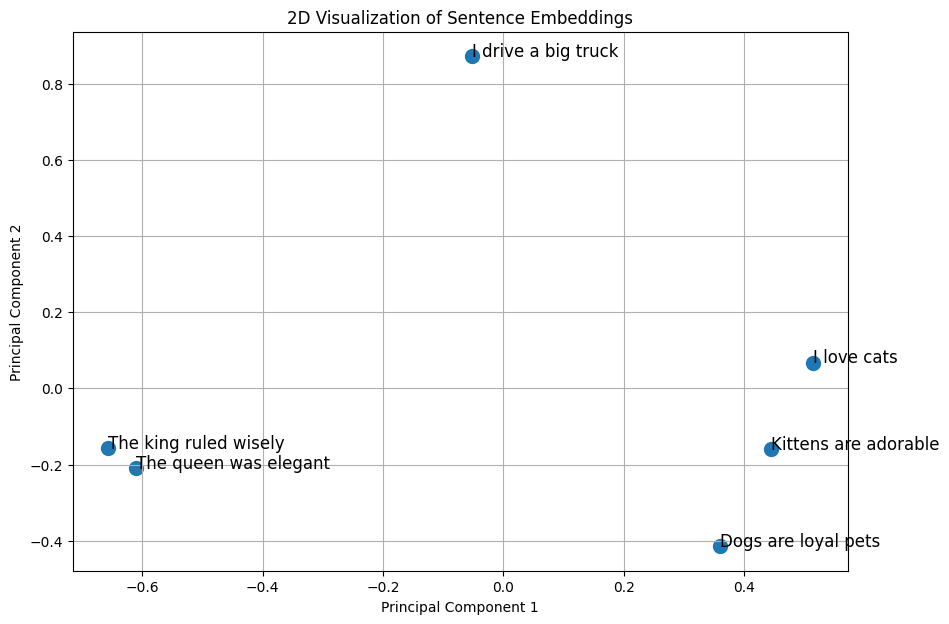

In [10]:
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings_real)

plt.figure(figsize=(10, 7))
plt.scatter(reduced[:, 0], reduced[:, 1], s=100)

for i, txt in enumerate(sentences):
    plt.annotate(txt, (reduced[i, 0], reduced[i, 1]), fontsize=12)

plt.title("2D Visualization of Sentence Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

## Summary

- We turned text into **vectors** (lists of numbers)
- Similar meanings = **close vectors**
- We can do **math on meaning**
- Real models (like the one used in ChatGPT) work the same way, just with more dimensions

**This is the foundation of modern AI: Search, Recommendation, Chatbots, RAG, etc.**